In [1]:
import pickle
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.regularizers import l2
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    Input,
    MaxPooling2D,
    RandomBrightness,
    RandomContrast,
    RandomCrop,
    RandomFlip,
    RandomRotation,
    RandomZoom,
)


I0000 00:00:1786820509.370046   36992 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786820509.434381   36992 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786820510.375854   36992 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
DATA_DIR = Path(r"/home/lenovo/Projects/Deep-Learning-Lab/data/cifar-10-batches-py")


def load_batch(file_path):
    with open(file_path, "rb") as f:
        batch = pickle.load(f, encoding="bytes")

    images = batch[b"data"]
    labels = np.array(batch[b"labels"])

    images = images.reshape(-1, 3, 32, 32)
    images = images.transpose(0, 2, 3, 1)

    return images, labels


# Load training data
X_train = []
y_train = []

for i in range(1, 6):
    images, labels = load_batch(DATA_DIR / f"data_batch_{i}")
    X_train.append(images)
    y_train.append(labels)

X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train, axis=0)

# Load test data
X_test, y_test = load_batch(DATA_DIR / "test_batch")

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000,)
Test images: (10000, 32, 32, 3)
Test labels: (10000,)


In [3]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

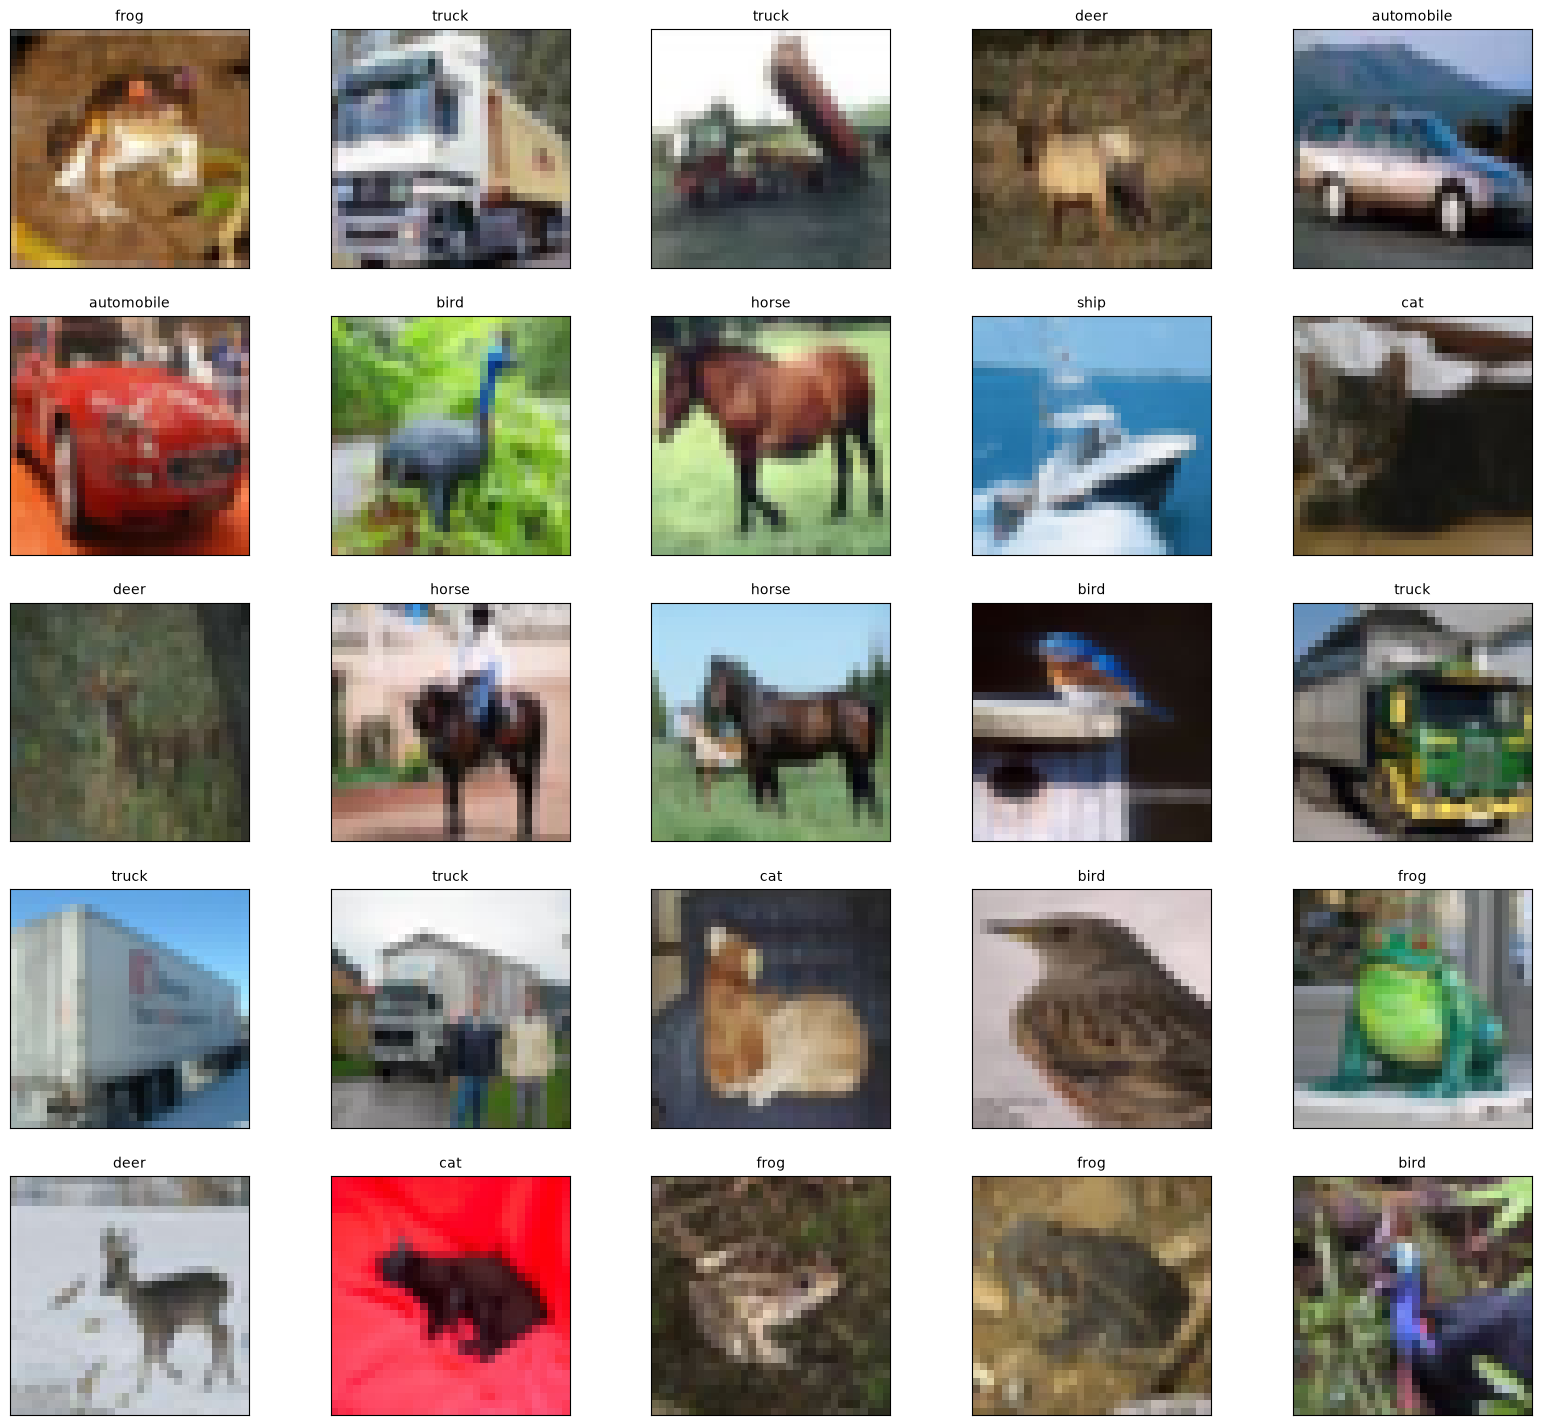

In [4]:
plt.figure(figsize=(20, 18))

for i in range(25):
    plt.subplot(5,5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]], fontsize=10)
    plt.xticks([])
    plt.yticks([])

plt.show()

In [5]:
# Data normalization
X_train = X_train.astype("float64") / 255.0
X_test = X_test.astype("float64") / 255.0

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [ ]:
model = Sequential([
    # Input
    Input(shape=(32, 32, 3)),
    
    # Data Augmentation
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1), 
    
    
    #Block one
    Conv2D(filters=32, kernel_size=(3,3), activation="relu", padding="same",kernel_regularizer = l2(1e-4)),
    BatchNormalization(),
    Conv2D(filters=32, kernel_size=(3,3), activation="relu", padding="same",kernel_regularizer = l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),
    
    # Block two
    Conv2D(filters=64, kernel_size = (3,3), activation = "relu", padding="same", kernel_regularizer = l2(1e-4)),
    BatchNormalization(),
    Conv2D(filters=64, kernel_size = (3,3), activation = "relu", padding="same", kernel_regularizer = l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.3),
    
    # Block three
    Conv2D(filters=128, kernel_size = (3,3), activation = "relu", padding="same", kernel_regularizer = l2(1e-4)),
    BatchNormalization(),
    Conv2D(filters=128, kernel_size = (3,3), activation = "relu", padding="same", kernel_regularizer = l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.4),
    
    GlobalAveragePooling2D(),
    
    # Classifier
    Dense(units=128, activation="relu"),
    Dropout(0.5),
    Dense(units=10, activation="softmax")
    
])

I0000 00:00:1786820516.082714   36992 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1765 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 306,602 (1.17 MB)

 Trainable params: 305,706 (1.17 MB)

 Non-trainable params: 896 (3.50 KB)

In [9]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate= 0.01),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [10]:
callback = [
    EarlyStopping(
        monitor = "val_loss",
        patience = 5,
        min_delta= 1e-4,
        restore_best_weights = True,
        start_from_epoch = 5,
        mode = "min",
        verbose = 1
        
        
    ),
    ReduceLROnPlateau(
        monitor = "val_loss",
        patience = 5,
        factor = 0.5, # 0 < Factor < 1
        min_delta = 1e-4,
        min_lr = 1e-6,
        verbose= 1
    )
]

In [11]:
history = model.fit(
    X_train,
    y_train, 
    epochs=50,
    validation_data = (X_val, y_val),
    verbose=1,
    batch_size = 64,
    callbacks = callback,
)

Epoch 1/50


E0000 00:00:1786820521.707336   36992 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1786820522.932216   37134 cuda_dnn.cc:461] Loaded cuDNN version 92400


625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.2850 - loss: 2.0005 - val_accuracy: 0.3398 - val_loss: 1.9838 - learning_rate: 0.0100
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.3949 - loss: 1.7788 - val_accuracy: 0.4035 - val_loss: 2.1580 - learning_rate: 0.0100
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.4288 - loss: 1.7299 - val_accuracy: 0.3651 - val_loss: 1.9515 - learning_rate: 0.0100
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.4491 - loss: 1.7039 - val_accuracy: 0.3983 - val_loss: 1.9053 - learning_rate: 0.0100
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.4647 - loss: 1.6751 - val_accuracy: 0.5132 - val_loss: 1.6446 - learning_rate: 0.0100
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.4750 - loss: 1.6403 - val_accuracy: 0.4447 - val_loss: 1.7530 - learning_rate: 0.0100
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.4872 - loss: 1.6259

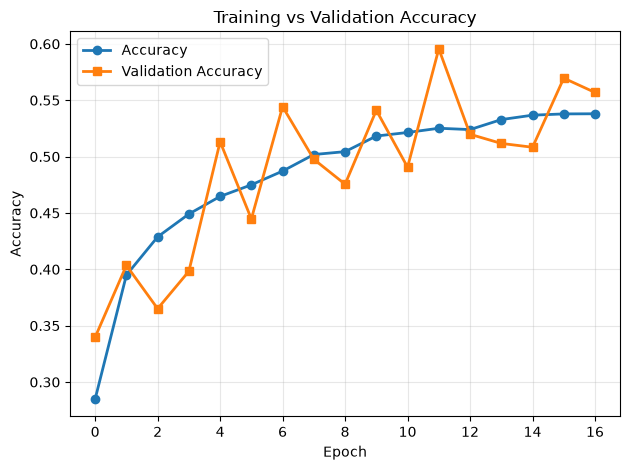

In [12]:
plt.figure()
plt.plot(history.history["accuracy"], linewidth=2, label="Accuracy", marker = "o")
plt.plot(history.history["val_accuracy"], linewidth=2, label= "Validation Accuracy", marker= "s")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

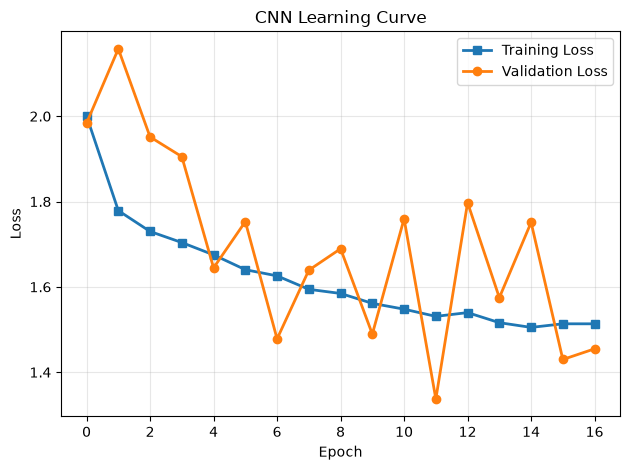

In [13]:
plt.figure()
plt.plot(history.history["loss"], linewidth=2, label="Training Loss", marker="s")
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth = 2, marker="o")

plt.legend()
plt.grid(True, alpha=0.3)

plt.title("CNN Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [14]:
y_prob = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_prob, axis =1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [15]:
print(y_prob.shape)
print(y_prob[1])

(10000, 10)
[1.8799866e-02 1.8087897e-02 9.9270583e-06 1.8545328e-06 7.1462305e-06
 5.8788103e-08 1.4638333e-06 1.2222073e-08 9.6269453e-01 3.9726050e-04]


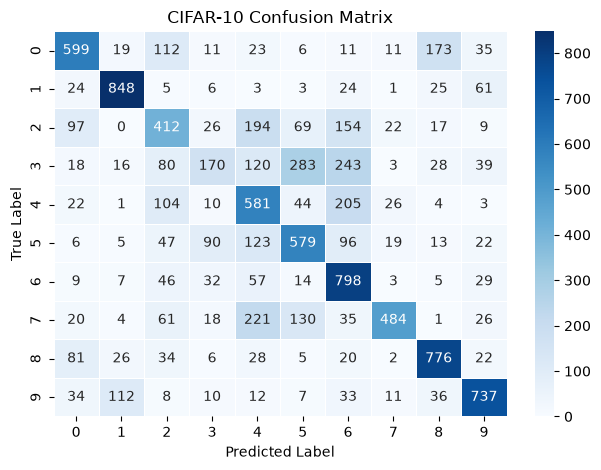

In [16]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    cbar=True,
    cmap="Blues",
    fmt="d",
    linewidth=0.5
)

plt.title("CIFAR-10 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [17]:
print(cm)

[[599  19 112  11  23   6  11  11 173  35]
 [ 24 848   5   6   3   3  24   1  25  61]
 [ 97   0 412  26 194  69 154  22  17   9]
 [ 18  16  80 170 120 283 243   3  28  39]
 [ 22   1 104  10 581  44 205  26   4   3]
 [  6   5  47  90 123 579  96  19  13  22]
 [  9   7  46  32  57  14 798   3   5  29]
 [ 20   4  61  18 221 130  35 484   1  26]
 [ 81  26  34   6  28   5  20   2 776  22]
 [ 34 112   8  10  12   7  33  11  36 737]]


In [18]:
print("Unique predictions:", np.unique(y_pred))
print("Prediction counts:", np.bincount(y_pred))

Unique predictions: [0 1 2 3 4 5 6 7 8 9]
Prediction counts: [ 910 1038  909  379 1362 1140 1619  582 1078  983]


In [19]:
print("Final training accuracy:",
      history.history["accuracy"][-1])

print("Final validation accuracy:",
      history.history["val_accuracy"][-1])

print("Best validation accuracy:",
      max(history.history["val_accuracy"]))

Final training accuracy: 0.5379999876022339
Final validation accuracy: 0.5569000244140625
Best validation accuracy: 0.5956000089645386


In [20]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.66      0.60      0.63      1000
           1       0.82      0.85      0.83      1000
           2       0.45      0.41      0.43      1000
           3       0.45      0.17      0.25      1000
           4       0.43      0.58      0.49      1000
           5       0.51      0.58      0.54      1000
           6       0.49      0.80      0.61      1000
           7       0.83      0.48      0.61      1000
           8       0.72      0.78      0.75      1000
           9       0.75      0.74      0.74      1000

    accuracy                           0.60     10000
   macro avg       0.61      0.60      0.59     10000
weighted avg       0.61      0.60      0.59     10000



In [21]:
print(f"Accuracy score :{accuracy_score(y_test, y_pred):0.2f}")
print(f"Recall score :{recall_score(y_test, y_pred, average="weighted"):0.2f}")
print(f"F1 score :{f1_score(y_test, y_pred, average = "weighted"):0.2f}")
print(f"precision score : {precision_score(y_test, y_pred, average="weighted"):0.2f}")


Accuracy score :0.60
Recall score :0.60
F1 score :0.59
precision score : 0.61


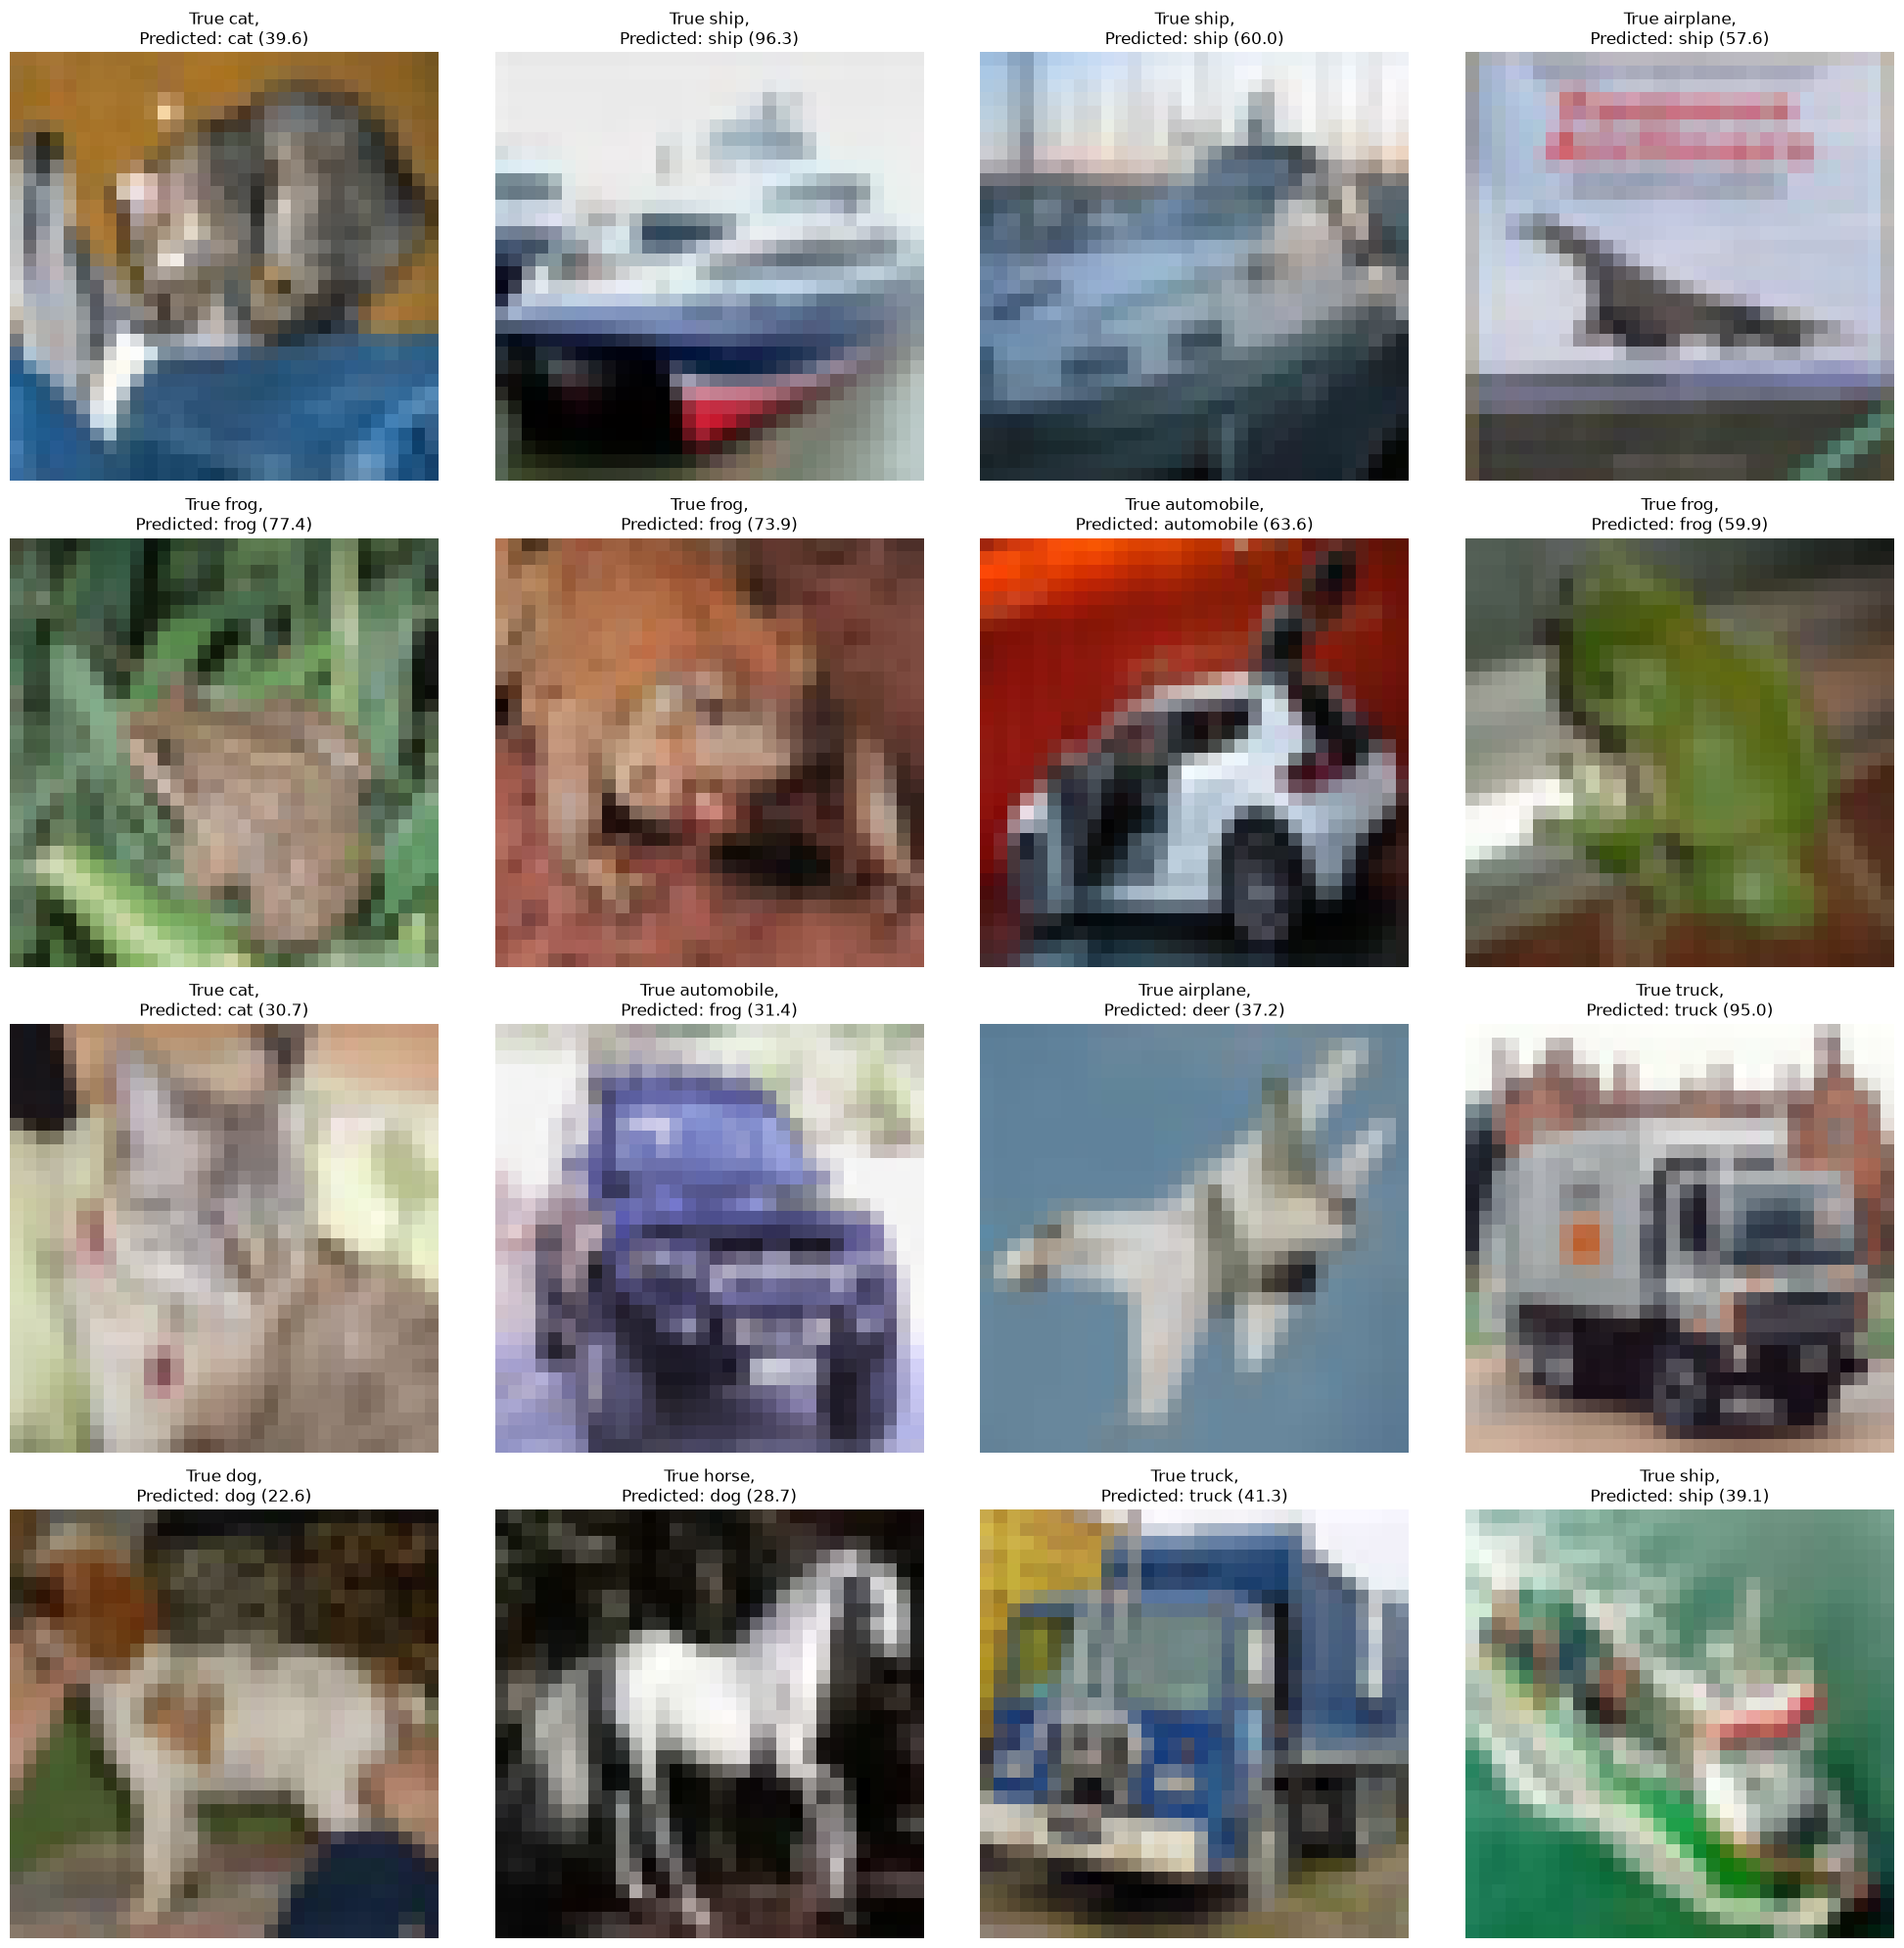

In [22]:
plt.figure(figsize=(20,20))

for i in range(16):
    plt.subplot(4,4, i + 1)
    plt.imshow(X_test[i])
    confidence = np.max(y_prob[i]) * 100
    plt.title(
        f"True {class_names[y_test[i]]},\nPredicted: {class_names[y_pred[i]]} ({confidence:0.1f})"
    )
    plt.axis("off")
    
    
plt.tight_layout()
plt.show()

In [23]:
wrong_indices = np.where(y_test != y_pred)[0]
print(len(wrong_indices))

4016


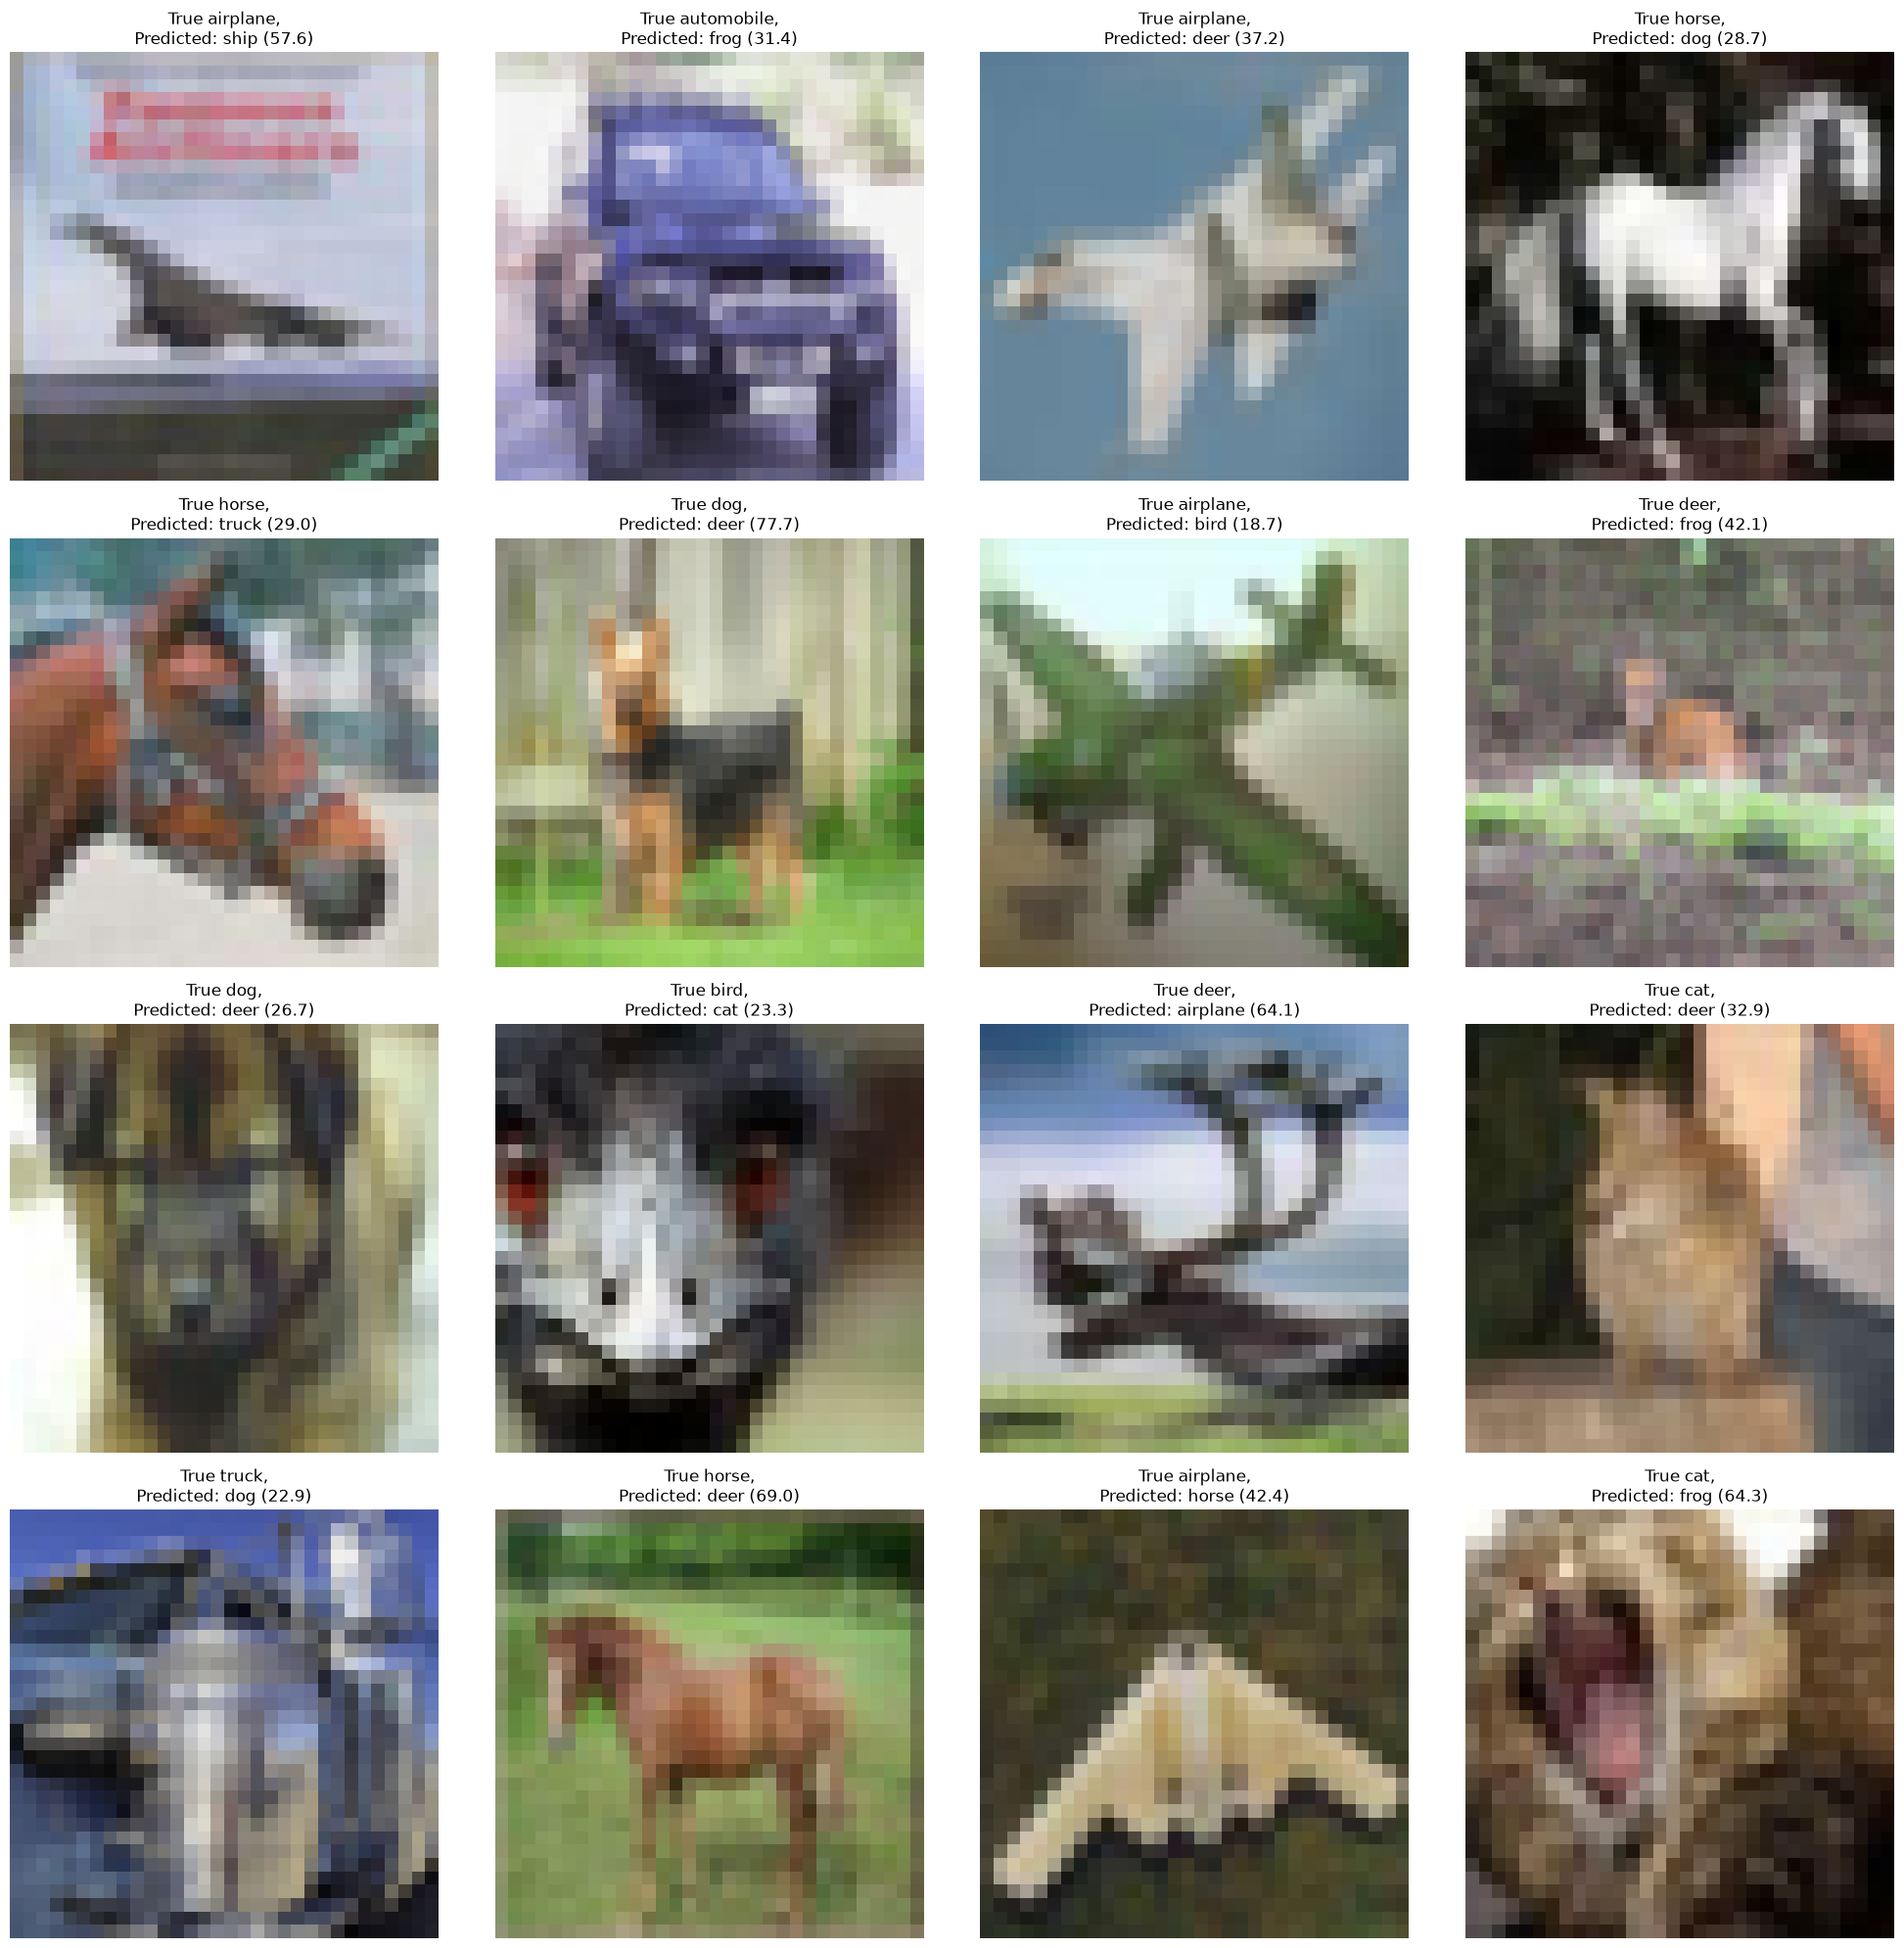

In [24]:
plt.figure(figsize=(20,20))
for i , idx in enumerate(wrong_indices[:16]):
    plt.subplot(4,4,i + 1)
    plt.imshow(X_test[idx])
    confidence = np.max(y_prob[idx]) * 100
    plt.title(
        f"True {class_names[y_test[idx]]},\nPredicted: {class_names[y_pred[idx]]} ({confidence:0.1f})"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()
    

In [25]:
model = Sequential([

    Input(shape=(32,32,3)),

    # Data augmentation
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),

    # Block 1
    Conv2D(32,(3,3),padding="same",activation="relu", kernel_regularizer=l2(1e-4)),
    
    BatchNormalization(),

    Conv2D(32,(3,3),padding="same",activation="relu",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),

    MaxPooling2D(),
    Dropout(0.25),


    # Block 2
    Conv2D(64,(3,3),padding="same",activation="relu",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),

    Conv2D(64,(3,3),padding="same",activation="relu",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),

    MaxPooling2D(),
    Dropout(0.3),


    # Block 3
    Conv2D(128,(3,3),padding="same",activation="relu",kernel_regularizer=l2(1e-4)
    ),
    BatchNormalization(),

    Conv2D(128,(3,3),padding="same",activation="relu",kernel_regularizer=l2(1e-4)
    ),
    BatchNormalization(),

    MaxPooling2D(),
    Dropout(0.4),


    # Classifier
    GlobalAveragePooling2D(),

    Dense(128,activation="relu",kernel_regularizer=l2(1e-4)),

    Dropout(0.5),

    Dense(10,activation="softmax")
])

